In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv("/Users/furkandurmaz/Library/Mobile Documents/com~apple~CloudDocs/KocUniversity/Projects/MarketinABTest/marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [6]:
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [11]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [30]:
# test group unique values:

df["test group"].unique()

array(['ad', 'psa'], dtype=object)

In [ ]:
# Genel Conv Rate
false_rate = (df["converted"] == True).mean()
print(false_rate)

0.02523886203220195


In [ ]:
# Grup A conv Rate
ConvRateofGroupAd = df[df["test group"] == "ad"]["converted"].mean()
print(ConvRateofGroupAd)


0.025546559636683747


In [ ]:
# Grup B conv Rate
ConvRateofGroupPsa = df[df["test group"] == "psa"]["converted"].mean()
print(ConvRateofGroupPsa)


0.01785410644448223


In [ ]:
# Outlier Check
df[["total ads","most ads hour"]].describe()

,total ads,most ads hour
count,588101.000000,588101.000000
mean,24.820876,14.469061
std,43.715181,4.834634
min,1.000000,0.000000
25%,4.000000,11.000000
50%,13.000000,14.000000
75%,27.000000,18.000000
max,2065.000000,23.000000


In [ ]:
# Count of ppl seen > 500 ads
df[df["total ads"]>500].count()

Unnamed: 0       585
user id          585
test group       585
converted        585
total ads        585
most ads day     585
most ads hour    585
dtype: int64

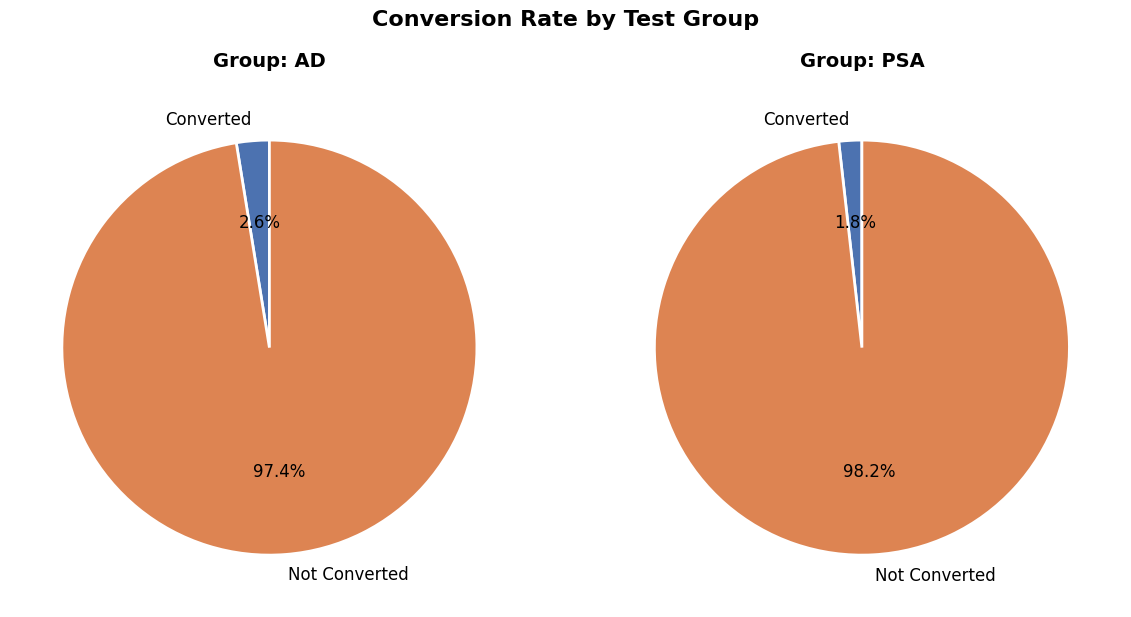

In [44]:
groups = df["test group"].unique()  # ["ad", "psa"]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors = ["#4C72B0", "#DD8452"]
for ax, group in zip(axes, groups):
    group_df = df[df["test group"] == group]["converted"]
    sizes    = group_df.value_counts().sort_index(ascending=False)  # True önce
    labels   = ["Converted", "Not Converted"]
    ax.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 12}
    )
    ax.set_title(f"Group: {group.upper()}", fontsize=14, fontweight="bold", pad=15)
fig.suptitle("Conversion Rate by Test Group", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

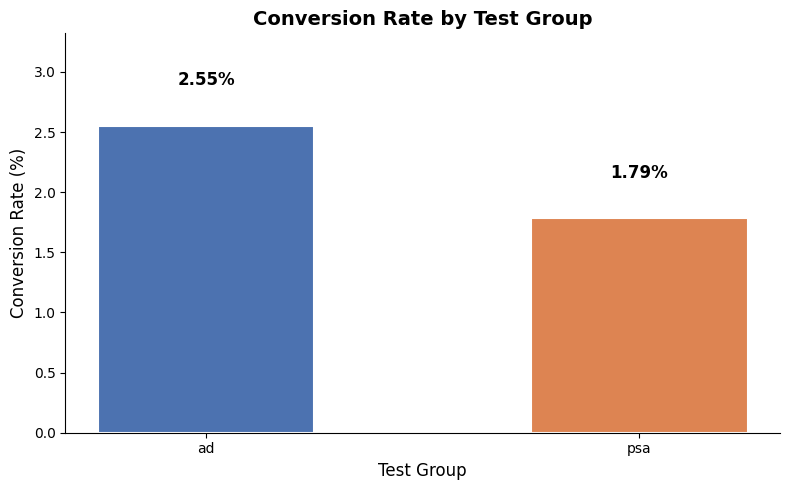

In [45]:
import matplotlib.pyplot as plt

# Her grup için conversion rate hesapla
conv_rates = df.groupby("test group")["converted"].mean() * 100  # yüzdeye çevir

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    conv_rates.index,
    conv_rates.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)

# Bar üzerine yüzde yaz
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

ax.set_title("Conversion Rate by Test Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Test Group", fontsize=12)
ax.set_ylabel("Conversion Rate (%)", fontsize=12)
ax.set_ylim(0, conv_rates.max() * 1.3)  # üstte boşluk bırak
ax.spines[["top", "right"]].set_visible(False)  # sade görünüm

plt.tight_layout()
plt.show()


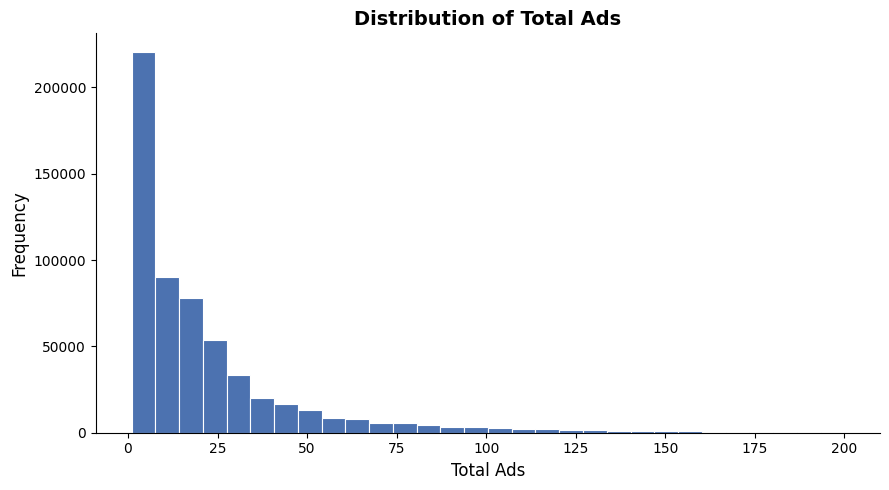

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df[df["total ads"] <= 200]["total ads"],  # ✅ filtre + sütun seçimi
    bins=30,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.8
)

ax.set_title("Distribution of Total Ads", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Ads", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# most ads hour top 3
df.groupby('most ads hour')['converted'].mean().sort_values(ascending=False).head(3)

most ads hour
16    0.030772
20    0.029803
15    0.029653
Name: converted, dtype: float64

In [ ]:
# most ads day top 3
df.groupby('most ads day')['converted'].mean().sort_values(ascending=False).head(3)

most ads day
Monday       0.032812
Tuesday      0.029840
Wednesday    0.024942
Name: converted, dtype: float64